In [1]:
import sys
import os

sys.path.append(os.path.realpath(os.path.join(os.getcwd(), '..', '..', '..', 'T5000', 'T5000-Base', 'Pylians3', 'library')))
sys.path.append(os.path.abspath('../src'))

from pathlib import Path
from tqdm import tqdm

import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import networkx as nx

project_root = Path().resolve().parent
sys.path.append(str(project_root))

from src.utils import load_config, radius_graph_pbc_batch
from src.validation import get_tpcf
from src.dataset import deterministic_sample, create_dataloader
from src.prior import scaled_log10_gaussian_mass_prior

import MAS_library as MASL
import Pk_library as PKL

/home/bartb/venvs/boids/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded 1800 simulations, each with 5000 halos
Using 200 simulations for analysis
L= 250.0 | mean=78.1, median=77.0, std=17.1, min=3, max=281, frac in [200,320]: 0.06%
L= 260.0 | mean=88.0, median=87.0, std=18.2, min=3, max=331, frac in [200,320]: 0.10%
L= 270.0 | mean=98.4, median=98.0, std=19.8, min=10, max=389, frac in [200,320]: 0.19%
L= 280.0 | mean=109.7, median=109.0, std=20.9, min=14, max=420, frac in [200,320]: 0.34%
L= 290.0 | mean=121.8, median=121.0, std=22.2, min=21, max=409, frac in [200,320]: 0.61%
L= 300.0 | mean=135.1, median=134.0, std=24.0, min=10, max=482, frac in [200,320]: 1.25%
L= 310.0 | mean=149.1, median=148.0, std=24.8, min=24, max=484, frac in [200,320]: 2.40%
L= 320.0 | mean=164.1, median=164.0, std=26.3, min=23, max=496, frac in [200,320]: 6.04%
L= 330.0 | mean=179.6, median=179.0, std=27.3, min=42, max=537, frac in [200,320]: 16.92%
L= 340.0 | mean=196.3, median=196.0, std=27.7, min=32, max=519, frac in [200,320]: 42.92%
L= 350.0 | mean=214.6, median=214.0

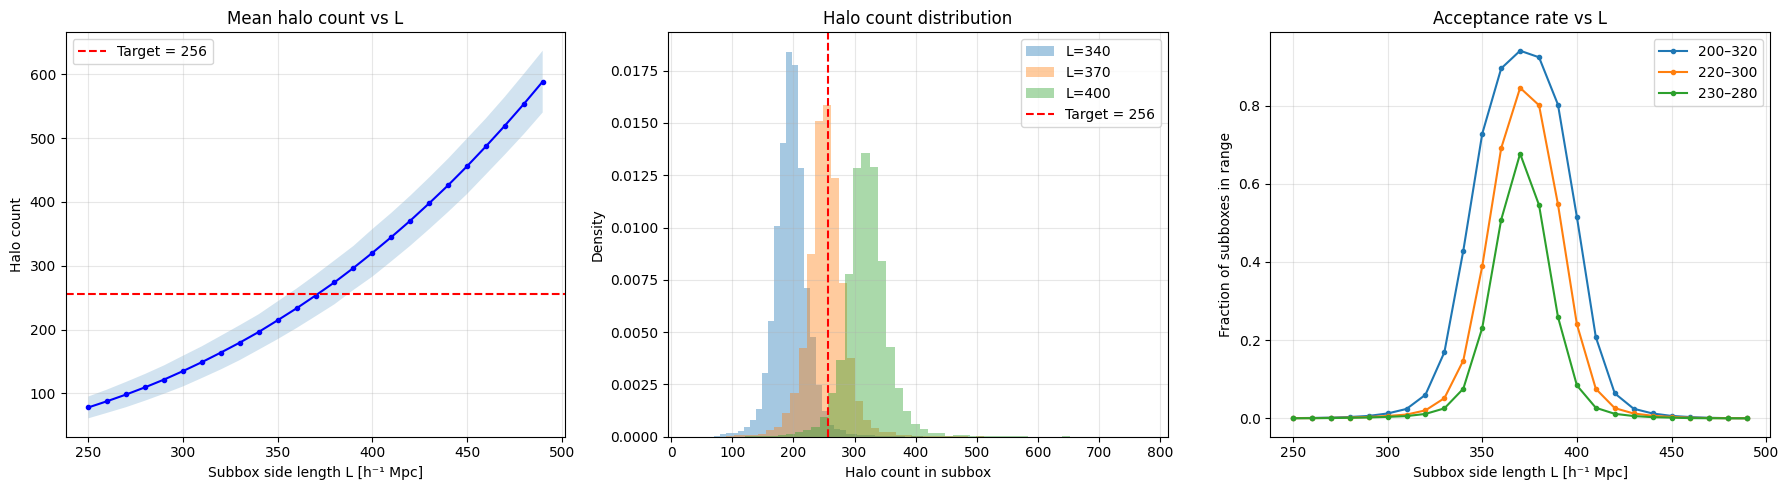


Best L (mean closest to 256): 370 h⁻¹ Mpc
  Mean count: 253.4
  Std:        32.5
  Median:     253.0
  [200, 320]: 94.0%


In [2]:
### Code to check optimal box size to obtain a mean of 256 halos per box

# ── Config ──────────────────────────────────────────────
DATA_DIR = "../../../T5000/Data"
SPLIT = "train"
BOX_SIZE = 1000.0  # h^-1 Mpc
TARGET_N = 256
N_RANDOM_PLACEMENTS = 100  # random subbox positions per simulation per L
L_VALUES = np.arange(250, 500, 10)  # sweep range for subbox side length

# ── Load data ───────────────────────────────────────────
halos = np.load(Path(DATA_DIR) / f"{SPLIT}_halos.npy")  # (N_sims, 5000, 7)
N_sims = halos.shape[0]
print(f"Loaded {N_sims} simulations, each with {halos.shape[1]} halos")

# Use a subset of simulations to keep this fast
N_sims_sample = min(200, N_sims)
sim_indices = np.random.choice(N_sims, N_sims_sample, replace=False)
print(f"Using {N_sims_sample} simulations for analysis")

# ── Subbox extraction with PBC ──────────────────────────
def count_halos_in_subbox(positions, corner, L, box_size=1000.0):
    """
    Count halos inside a cubic subbox [corner, corner+L)^3 with PBC wrapping.
    """
    # Shift so corner is at origin, then wrap
    shifted = (positions - corner) % box_size
    # Halos inside the subbox have all coords in [0, L)
    inside = np.all(shifted < L, axis=1)
    return inside.sum()

# ── Sweep L values ──────────────────────────────────────
results = {}

for L in L_VALUES:
    counts = []
    for sim_idx in sim_indices:
        pos = halos[sim_idx, :, :3]  # (5000, 3) positions in [0, 1000)
        for _ in range(N_RANDOM_PLACEMENTS):
            corner = np.random.uniform(0, BOX_SIZE, size=3)
            n = count_halos_in_subbox(pos, corner, L)
            counts.append(n)
    
    counts = np.array(counts)
    results[L] = counts
    print(f"L={L:>6.1f} | mean={counts.mean():.1f}, median={np.median(counts):.1f}, "
          f"std={counts.std():.1f}, min={counts.min()}, max={counts.max()}, "
          f"frac in [200,320]: {np.mean((counts >= 200) & (counts <= 320)):.2%}")

# ── Plot 1: Mean halo count vs L ────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

means = [results[L].mean() for L in L_VALUES]
stds = [results[L].std() for L in L_VALUES]

ax = axes[0]
ax.plot(L_VALUES, means, 'b-o', markersize=3)
ax.fill_between(L_VALUES, np.array(means) - np.array(stds), 
                np.array(means) + np.array(stds), alpha=0.2)
ax.axhline(TARGET_N, color='r', linestyle='--', label=f'Target = {TARGET_N}')
ax.set_xlabel('Subbox side length L [h⁻¹ Mpc]')
ax.set_ylabel('Halo count')
ax.set_title('Mean halo count vs L')
ax.legend()
ax.grid(True, alpha=0.3)

# ── Plot 2: Distribution at a few key L values ──────────
ax = axes[1]
# Find L closest to target
best_L_idx = np.argmin(np.abs(np.array(means) - TARGET_N))
best_L = L_VALUES[best_L_idx]
show_Ls = [best_L - 30, best_L, best_L + 30]
show_Ls = [L for L in show_Ls if L in results]

for L in show_Ls:
    ax.hist(results[L], bins=50, alpha=0.4, label=f'L={L:.0f}', density=True)
ax.axvline(TARGET_N, color='r', linestyle='--', label=f'Target = {TARGET_N}')
ax.set_xlabel('Halo count in subbox')
ax.set_ylabel('Density')
ax.set_title('Halo count distribution')
ax.legend()
ax.grid(True, alpha=0.3)

# ── Plot 3: Fraction of subboxes within acceptable range ─
ax = axes[2]
for lo, hi, label in [(200, 320, '200–320'), (220, 300, '220–300'), (230, 280, '230–280')]:
    fracs = [np.mean((results[L] >= lo) & (results[L] <= hi)) for L in L_VALUES]
    ax.plot(L_VALUES, fracs, '-o', markersize=3, label=f'{label}')
ax.set_xlabel('Subbox side length L [h⁻¹ Mpc]')
ax.set_ylabel('Fraction of subboxes in range')
ax.set_title('Acceptance rate vs L')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('subbox_L_analysis.png', dpi=150)
plt.show()

# ── Print recommendation ────────────────────────────────
print(f"\n{'='*60}")
print(f"Best L (mean closest to {TARGET_N}): {best_L:.0f} h⁻¹ Mpc")
print(f"  Mean count: {results[best_L].mean():.1f}")
print(f"  Std:        {results[best_L].std():.1f}")
print(f"  Median:     {np.median(results[best_L]):.1f}")
print(f"  [200, 320]: {np.mean((results[best_L] >= 200) & (results[best_L] <= 320)):.1%}")
print(f"{'='*60}")

In [4]:
### Extract subboxes
import numpy as np
import pandas as pd
from pathlib import Path

DATA_DIR = "../../../T5000/Data"
OUT_DIR = "../../Data/subboxes"
L = 370
BOX_SIZE = 1000
N_SUBBOXES = 10
COUNT_RANGE = (200, 320)
MAX_COUNT = 320

Path(OUT_DIR).mkdir(parents=True, exist_ok=True)

for split in ["train", "test"]:
    halos_all = np.load(Path(DATA_DIR) / f"{split}_halos.npy")
    params_df = pd.read_csv(Path(DATA_DIR) / f"{split}_cosmology.csv")
    
    N_sims = halos_all.shape[0]
    
    subbox_list = []
    counts_list = []
    params_list = []
    
    for sim_idx in range(N_sims):
        halos = halos_all[sim_idx]  # (5000, 7)
        
        for _ in range(N_SUBBOXES):
            corner = np.random.uniform(0, BOX_SIZE, size=3)
            
            pos = halos[:, :3]
            shifted_pos = (pos - corner) % BOX_SIZE
            mask = np.all(shifted_pos < L, axis=1)
            
            count = mask.sum()
            if count < COUNT_RANGE[0] or count > COUNT_RANGE[1]:
                continue
            
            sub = halos[mask].copy()
            sub[:, :3] = shifted_pos[mask]
            
            padded = np.zeros((MAX_COUNT, 7), dtype=np.float32)
            padded[:count] = sub
            
            subbox_list.append(padded)
            counts_list.append(count)
            params_list.append(params_df.values[sim_idx])
    
    subbox_arr = np.stack(subbox_list)
    counts_arr = np.array(counts_list)
    
    np.save(Path(OUT_DIR) / f"{split}_subbox_halos.npy", subbox_arr)
    np.save(Path(OUT_DIR) / f"{split}_subbox_counts.npy", counts_arr)
    
    out_params_df = pd.DataFrame(params_list, columns=params_df.columns)
    out_params_df.to_csv(Path(OUT_DIR) / f"{split}_cosmology.csv", index=False)
    
    print(f"{split}: {len(subbox_list)} subboxes from {N_sims} simulations "
          f"(mean count: {counts_arr.mean():.1f}, std: {counts_arr.std():.1f})")

FileNotFoundError: [Errno 2] No such file or directory: 'Data/train_halos.npy'